Cell 1 - Imports

In [2]:
import pickle 
import pandas as pd  
import numpy as np 
import matplotlib.pyplot  as plt 
import seaborn as sns 

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)

Cell 2 - Load Model
-

In [3]:
model = pickle.load(open("../models/best_model.pkl","rb"))

tfidf = pickle.load(open("../models/tfidf.pkl","rb"))

scaler = pickle.load(open("../models/scaler.pkl","rb"))

Cell 3 - Load Dataset
-

In [4]:
df = pd.read_csv("../data/processed_jobs.csv")

df.head()

,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,...,contact_email,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake,combined_text
0,1,Software Engineer,We are looking for responsibilities fast-paced...,Candidates should have dynamic team skills fas...,We offer required skills fast-paced skills req...,Company_543,Our company growth fast-paced responsibilities...,Marketing,Contract,"Toronto, Canada",...,hr312@company.com,https://www.company.com,0,3,Management,0,NaN,89,0,software engineerour company growth fast paced...
1,2,Content Writer,We are looking for required support experience...,Candidates should have required team fast-pace...,We offer fast-paced dynamic dynamic strategy g...,Company_192,Our company fast-paced opportunity innovation ...,Finance,Full-time,"Toronto, Canada",...,hr127@company.com,https://www.company.com,0,10,Development,1,NaN,89,0,content writerour company fast paced opportuni...
2,3,Customer Support Specialist,We are looking for dynamic required fast-paced...,Candidates should have preferred knowledge opp...,We offer skills experience required growth res...,NaN,We are global innovation growth skills knowled...,Healthcare,Internship,Remote,...,job92@gmail.com,NaN,0,6,Support,0,Suspicious email,69,1,customer support specialistwe global innovatio...
3,4,Data Analyst,We are looking for collaboration skills suppor...,Candidates should have innovation team require...,We offer strategy strategy dynamic support opp...,Company_95,Our company fast-paced support team strategy i...,Healthcare,Part-time,"Berlin, Germany",...,hr366@company.com,https://www.company.com,1,4,Management,1,NaN,89,0,data analystour company fast paced support tea...
4,5,Graphic Designer,We are looking for team growth growth fast-pac...,Candidates should have experience preferred kn...,We offer opportunity skills responsibilities c...,NaN,We are global experience skills preferred fast...,Retail,Part-time,"London, UK",...,job359@gmail.com,NaN,0,5,Management,0,No salary info,69,1,graphic designerwe global experience skills pr...


Cell 4 - Recreate Features
-

In [5]:
text_columns = [
    "job_title",
    "company_profile",
    "requirements",
    "job_description",
    "benefits",
    "industry",
    "department",
    "job_function"


]

df["combined_text"] = "" 

for col in text_columns:
    df["combined_text"] += df[col].fillna("") + " " 

Cell 5
-

In [6]:
text_features = tfidf.transform(
    df["combined_text"]
)

Cell 6
-

In [7]:
from scipy.sparse import hstack 

structured_cols = [
    "required_experience_years",
    "num_open_positions",
    "has_logo",
    "telecommuting"
]

structured = scaler.transform(
    df[structured_cols]
)

X = hstack([
    text_features,
    structured
])

y = df["is_fake"]



Cell 7
-

In [8]:
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Cell 8
-

In [9]:
pred = model.predict(X_test)

Cell 9 - Confusion Matrix
-

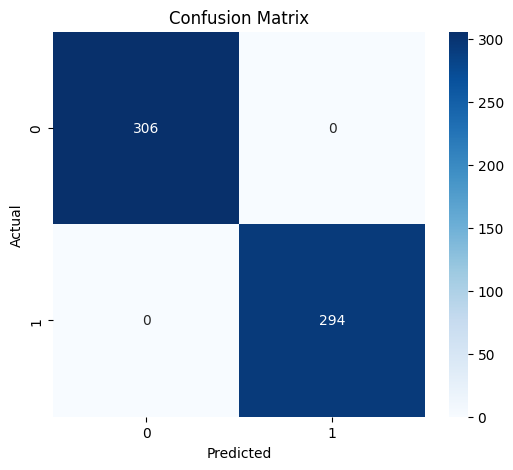

<Figure size 640x480 with 0 Axes>

In [10]:
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

plt.savefig("../reports/confusion_matrix.png")

Cell 10  - Classification Report
-

In [11]:
print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



Cell 11 - ROC Curve
-

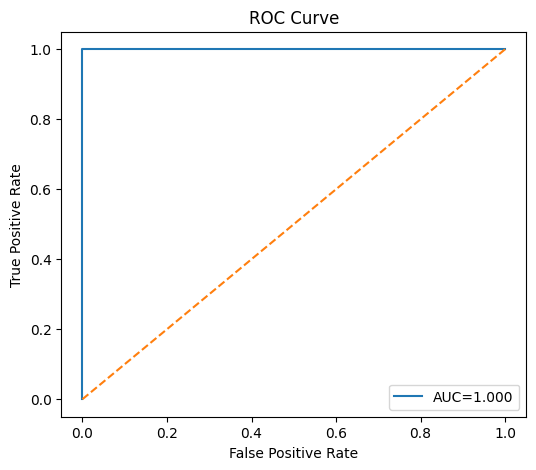

<Figure size 640x480 with 0 Axes>

In [ ]:
prob = model.predict_proba(
    X_test
)[:,1]

fpr,tpr,_=roc_curve(
    y_test,
    prob
)

auc = roc_auc_score(
    y_test,
    prob
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}" 

)

plt.plot([0,1],[0,1],"--")

plt.legend()

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.savefig("../reports/roc_curve.png", dpi=300, bbox_inches="tight") 

plt.show()


Cell 12 : Precision-Recall Curve
-

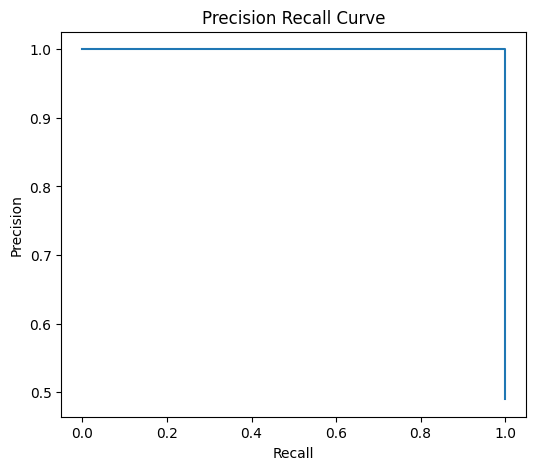

<Figure size 640x480 with 0 Axes>

In [13]:
precision,recall,_=precision_recall_curve(
    y_test,
    prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

plt.savefig("../reports/precision_recall_curve.png") 

Cell 13 : True Positive Words (Fake Job Indicators)
-

In [14]:
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

importance = pd.DataFrame({

    "word":feature_names,

    "weight":coefficients[:len(feature_names)]
})

importance.sort_values(
    by="weight",
    ascending=False
).head(20)


,word,weight
198,global,7.798227
336,manager global,3.134881
3,analyst global,2.829136
648,writer global,1.910431
85,designer global,1.884958
152,engineer global,1.862102
73,coordinator global,1.805907
557,specialist global,1.793056
160,executive global,1.790086
214,global team,1.602436


Cell 14 - Visualize
-

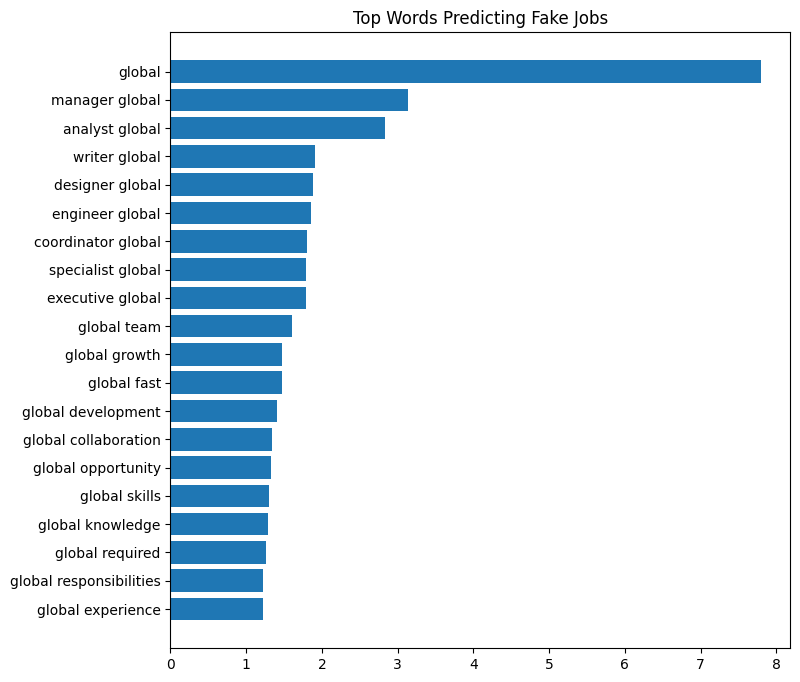

In [15]:
top_words = importance.sort_values(
    by="weight",
    ascending=False
).head(20)

plt.figure(figsize=(8,8))

plt.barh(
    top_words["word"],
    top_words["weight"]
)

plt.title("Top Words Predicting Fake Jobs") 

plt.gca().invert_yaxis()

plt.show()

Cell 15
-

In [16]:
importance.sort_values(
    by="weight"
).head(20)

,word,weight
52,company,-5.614829
287,knowledge,-3.520835
365,opportunity,-3.401103
161,experience,-3.388953
23,collaboration,-3.330913
258,innovation,-3.214289
617,team,-3.210382
524,skills,-3.196988
558,strategy,-3.173285
86,development,-3.164598


Cell 16: Plot
-

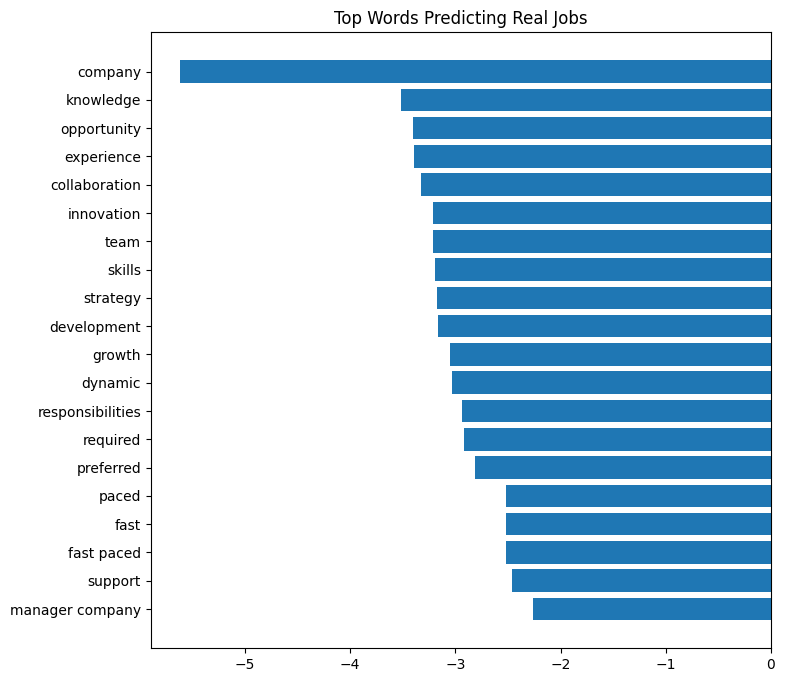

In [17]:
real = importance.sort_values(
    by="weight"
).head(20)

plt.figure(figsize=(8,8))

plt.barh(
    real["word"],
    real["weight"]
)

plt.title("Top Words Predicting Real Jobs")

plt.gca().invert_yaxis()

plt.show()

Cell 17 - Prediction Examples
-

In [18]:
examples = df.sample(10, random_state=42)

X_sample = hstack([
    tfidf.transform(examples["combined_text"]),
    scaler.transform(examples[structured_cols])
])

examples["Prediction"] = model.predict(X_sample)

examples[
    [
        "job_title",
        "is_fake",
        "Prediction"
    ]
]

,job_title,is_fake,Prediction
1801,Product Manager,1,1
1190,Marketing Manager,0,0
1817,Customer Support Specialist,0,0
251,Business Analyst,0,0
2505,Software Engineer,1,1
1117,Marketing Manager,1,1
1411,Data Analyst,1,1
2113,Graphic Designer,1,1
408,Software Engineer,0,0
2579,Marketing Manager,1,1


Cell 18 - Results
-

In [19]:
report = classification_report(
    y_test,
    pred,
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    "../models/evaluation_report.csv"
)